In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [8]:
# Task 1.1 - Detect PyTorch version & install matching PyG extensions
import torch
print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.version.cuda}")

# Build the correct wheel URL dynamically
TORCH_VERSION = torch.__version__.split('+')[0]  # e.g. "2.10.0"
CUDA_TAG = f"cu{torch.version.cuda.replace('.', '')}" if torch.cuda.is_available() else "cpu"
WHEEL_URL = f"https://data.pyg.org/whl/torch-{TORCH_VERSION}+{CUDA_TAG}.html"
print(f"Using wheel URL: {WHEEL_URL}")

!pip install torch-geometric
!pip install torch-scatter torch-sparse torch-cluster -f {WHEEL_URL}


PyTorch: 2.10.0+cu128
CUDA: 12.8
Using wheel URL: https://data.pyg.org/whl/torch-2.10.0+cu128.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 81.4 MB/s eta 0:00:00
Looking in links: https://data.pyg.org/whl/torch-2.10.0+cu128.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 32.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 98.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 26.2 MB/s eta 0:00:00


In [ ]:
import torch
import torch.nn as nn
from torch_geometric.nn import PointNetConv, fps, radius
from torch_geometric.data import Batch

# create a dummy input point cloud (N=1024, 3 coords)
pos = torch.rand(1024, 3)
batch = torch.zeros(1024, dtype=torch.long)
if torch.cuda.is_available():
    pos, batch = pos.cuda(), batch.cuda()

# Define PyG Set Abstraction components
ratio = 0.25 # keep 256 points
r = 0.2 # radius
mlp = nn.Sequential(
    nn.Linear(3, 64), nn.ReLU(),
    nn.Linear(64, 64), nn.ReLU(),
    nn.Linear(64, 128)
)
conv = PointNetConv(local_nn=mlp)
if torch.cuda.is_available():
    conv = conv.cuda()

# Run grouping and convolution
idx = fps(pos, batch, ratio=ratio)
row, col = radius(pos, pos[idx], r, batch, batch[idx], max_num_neighbors=32)
edge_index = torch.stack([col, row], dim=0)
new_pos = pos[idx]
new_features = conv(x=None, pos=pos, edge_index=edge_index)

# print output shape — should be (256, 128)
print(f"Output features shape: {new_features.shape}")


Output features shape: torch.Size([1024, 128])


In [7]:
!pip install laspy[lazrs] pysheds geopandas rasterio scipy \
             scikit-learn matplotlib numpy pandas pyproj \
             shapely tqdm joblib whitebox folium -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.0/74.0 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 649.3/649.3 kB 53.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.1/86.1 kB 10.7 MB/s eta 0:00:00


In [ ]:
import os
os.chdir('/content/drive/MyDrive/GEO-INTEL_pipeline')
print("Working dir:", os.getcwd())
print("Files:", os.listdir('.'))


Working dir: /content/drive/MyDrive/GEO-INTEL_pipeline
Files: ['__pycache__', 'outputs', 'run_pipeline.py', 'InteractiveMap.py', 'Hydrology_pipeline.py', 'All_Village_Summaries', 'lulc_pipeline.py', 'Datasets', 'report.pdf', 'pointnet_feature_extractor.py', 'GEO-INTEL_pipeline.py', 'compare_pipelines.py']


Working directory changed to: /content/drive/MyDrive/GEO-INTEL_pipeline
  TASK 3.1 — ACCURACY COMPARISON: RF vs RF+PointNet++ Hybrid
  Village: DEVDI_POINT CLOUD (511671)

  📂 Found: /content/drive/MyDrive/GEO-INTEL_pipeline/Datasets/Gujrat_Point_Cloud/DEVDI_POINT CLOUD (511671).las

── Loading Point Cloud ──
  Loaded 64,622,538 points from DEVDI_POINT CLOUD (511671).las

── Computing Base Features (12 RF features) ──
  Subsampling to 500,000 points for feature computation…
  [PointNet++] GPU detected. Extracting 128-dim geometric features...
Extracting PointNet++ features for 500000 points on cuda...
  [PointNet++] Success. Total ML features is now 140.
  Feature computation took 26.9s

  ✅ PointNet++ features detected: 128 columns

──────────────────────────────────────────────────
  🌲 MODEL A: Random Forest Only (12 features)
──────────────────────────────────────────────────
  ⚠️ No ASPRS labels found — creating pseudo-labels via grid filter
  Pseudo-labels: 62,790 ground / 437,210

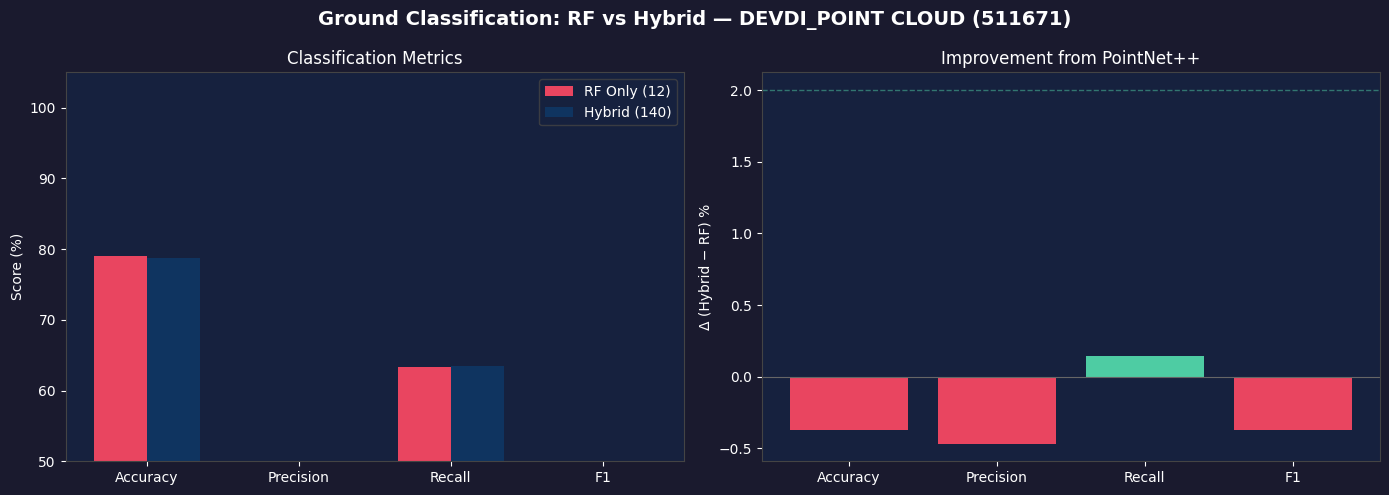


  📊 Comparison chart saved → ./outputs/DEVDI_POINT CLOUD (511671)_ModelComparison.png

✅ Task 3.1 comparison complete.


In [ ]:
import os
import sys

# Change to your main project folder where the .py files are uploaded
project_dir = '/content/drive/MyDrive/GEO-INTEL_pipeline'

if os.path.exists(project_dir):
    os.chdir(project_dir)
    print(f"Working directory changed to: {os.getcwd()}")

    # Check if the file is actually here
    if not os.path.exists('compare_pipelines.py'):
        print("⚠️ compare_pipelines.py is NOT in this folder! Did you forget to upload it?")
    else:
        sys.argv = ['compare', 'DEVDI_POINT CLOUD (511671)']
        with open('compare_pipelines.py', 'r') as f:
            exec(f.read())
else:
    print(f"Directory {project_dir} does not exist. Please check the path.")


In [9]:
import os
import sys

# Change to your main project folder where the .py files are uploaded
project_dir = '/content/drive/MyDrive/GEO-INTEL_pipeline'

if os.path.exists(project_dir):
    os.chdir(project_dir)
    print(f"Working directory changed to: {os.getcwd()}")

    # Check if the file is actually here
    if not os.path.exists('compare_pipelines.py'):
        print("⚠️ compare_pipelines.py is NOT in this folder! Did you forget to upload it?")
    else:
        sys.argv = ['compare', 'DEVDI_POINT CLOUD (511671)']
        with open('compare_pipelines.py', 'r') as f:
            exec(f.read())
else:
    print(f"Directory {project_dir} does not exist. Please check the path.")

Working directory changed to: /content/drive/MyDrive/GEO-INTEL_pipeline
  TASK 3.1 — ACCURACY COMPARISON: RF vs RF+PointNet++ Hybrid
  Village: DEVDI_POINT CLOUD (511671)

  📂 Found: /content/drive/MyDrive/GEO-INTEL_pipeline/Datasets/Gujrat_Point_Cloud/DEVDI_POINT CLOUD (511671).las

── Loading Point Cloud ──
  Loaded 64,622,538 points from DEVDI_POINT CLOUD (511671).las

── Computing Base Features (12 RF features) ──
  Subsampling to 500,000 points for feature computation…
  [PointNet++] GPU detected. Extracting 128-dim geometric features...
Extracting PointNet++ features for 500000 points on cuda...
  [PointNet++] Success. Total ML features is now 140.
  Feature computation took 25.7s

  ✅ PointNet++ features detected: 128 columns

──────────────────────────────────────────────────
  🌲 MODEL A: Random Forest Only (12 features) [CACHED]
──────────────────────────────────────────────────
  Accuracy:         79.08%
  Ground Precision: 32.78%
  Ground Recall:    63.39%
  Ground F1:      